<a href="https://colab.research.google.com/github/shian0604/CSST104-3B-2AY2526/blob/main/Laboratory_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#===================================#
# TASK 1: Import required Libraries #
#===================================#

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import geopandas as gpd
import folium

        featurecla  scalerank  LABELRANK                   SOVEREIGNT SOV_A3  \
0  Admin-0 country          1          6                         Fiji    FJI   
1  Admin-0 country          1          3  United Republic of Tanzania    TZA   
2  Admin-0 country          1          7               Western Sahara    SAH   
3  Admin-0 country          1          2                       Canada    CAN   
4  Admin-0 country          1          2     United States of America    US1   

   ADM0_DIF  LEVEL               TYPE TLC                        ADMIN  ...  \
0         0      2  Sovereign country   1                         Fiji  ...   
1         0      2  Sovereign country   1  United Republic of Tanzania  ...   
2         0      2      Indeterminate   1               Western Sahara  ...   
3         0      2  Sovereign country   1                       Canada  ...   
4         1      2            Country   1     United States of America  ...   

      FCLASS_TR     FCLASS_ID     FCLASS_PL 

<Axes: >

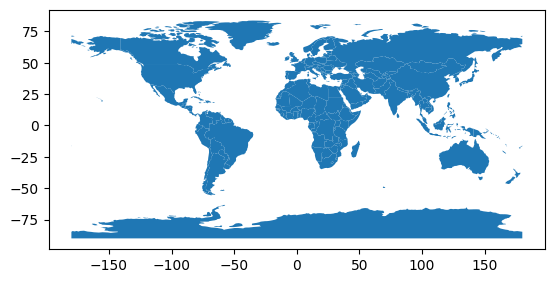

In [2]:
#==============================#
# TASK 2: Load Natural Dataset #
#==============================#

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

print(world.head())
world.plot()

# **TASK 2: Load Natural Dataset**


---

Guide Questions


1.   How many columns does the dataset contain?


> The provided dataset has 5 rows and 169 columns.


2.   What types of Geometries are included?


> The types of Geometries included in the dataset are Multipolygons and Polygons to represent the shapes of the map.




3.  What does the geometry column represent?


> The geometry column represents the shape of each country. It stores the actual spatial shape, outlines or boundaries, that define the countries location on the earth.







In [3]:
#===============================================#
# TASK 3: Check the Coordinate Reference System #
#===============================================#

print("current CRS: ", world.crs)

current CRS:  EPSG:4326


# **Task 3: Check the Coordinate Reference System**


---


1.   What does EPSG:4326 represent?


> The EPSG:4326 is the standard coordinate system that uses latitude and longitude values in degrees.


2.   Why is CRS importan in spatial analysis?


> CRS is an essential in spatial analysis as it enables spatial data to correctly line up in the map. Without it, meeasurements like distance or area could be misleading because coordinates might not be interpreted consistently.






In [5]:
#====================================================#
# TASK 4: Convert to Metric CRS for Area Calculation #
#====================================================#

world_projected = world.to_crs(epsg=3857)

world_projected["area_m2"] = world_projected.geometry.area

print(world_projected[["ADMIN", "area_m2"]].head())
print("\nArea Reprojection Complete")

                         ADMIN       area_m2
0                         Fiji  2.128334e+10
1  United Republic of Tanzania  9.522552e+11
2               Western Sahara  1.171023e+11
3                       Canada  5.216648e+13
4     United States of America  2.186228e+13

Area Reprojection Complete


# **Task 4: Convert to Metric CRS for Area Calculation**


---


1.   Why can't we compute area accurately using EPSG:4326?


> Inaccuracy happens as the system utilizes degrees and not meters. Degrees don't translate directly into real-world distances or areas, so calculations would be distorted.


2.   What unit is EPSG:4356 based on?


> EPSG: 4356 is based on meters. Thus, it is inaccurate for computing area.






In [6]:
#======================================#
# TASK 5: Extract Centroid Coordinates #
#======================================#

world_projected["centroid"] = world_projected.geometry.centroid
world_projected["x"] = world_projected.centroid.x
world_projected["y"] = world_projected.centroid.y

print(world_projected[["ADMIN", "x", "y"]].head())

                         ADMIN             x             y
0                         Fiji  1.824878e+07 -1.958098e+06
1  United Republic of Tanzania  3.869296e+06 -7.003071e+05
2               Western Sahara -1.348403e+06  2.794163e+06
3                       Canada -1.079779e+07  1.044422e+07
4     United States of America -1.329713e+07  6.667416e+06


# **Task 5: Extract Centroid Coordinates**


---


1.   What is a centroid?


> A centroid is the "center point" of a shape. It's like the balance point of a polygon


2.   How can centroid coordinates be used in clustering?


> In clustering, centroids acts as a reference point for grouping coordinates or regions. Clustering Algorithms can use them to find spatial patterns or group nearby locations.




3.   Why do we extract X and Y separately?



> The coordinates, longitude (x) and latitude (Y), when separated, makes it easier to use the coordinates in calculations, visualizations, or machine learning models










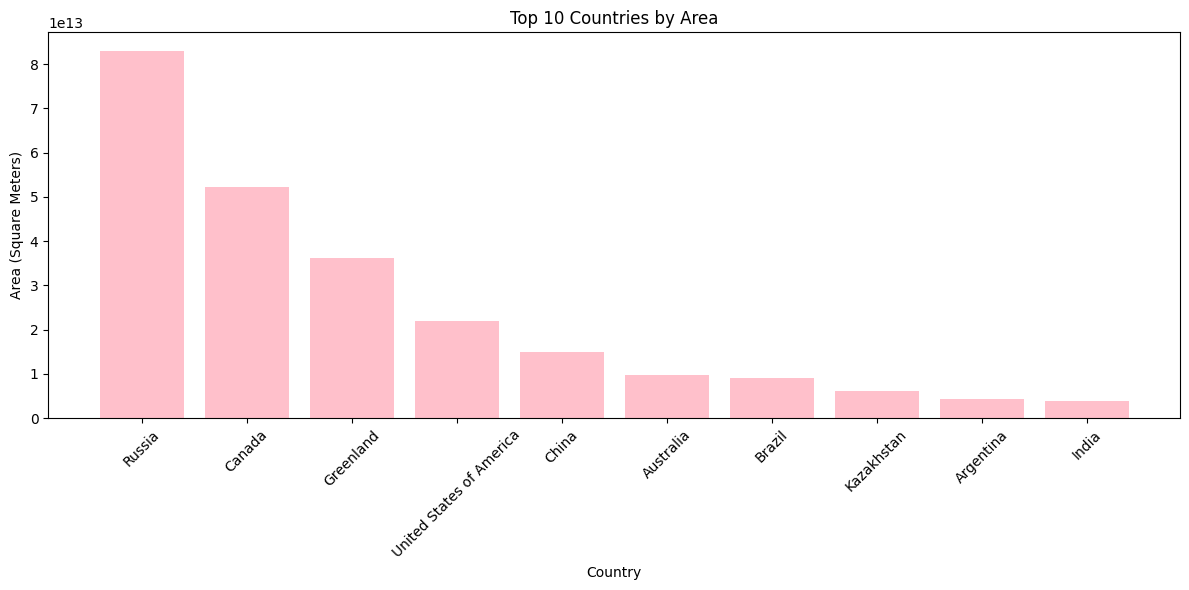

In [9]:
#==============================================#
# TASK 5: Plot top 5 Largest countries by Area #
#==============================================#

remove = world_projected[world_projected['ADMIN'] != 'Antarctica']
top_10_countries = remove.nlargest(10, 'area_m2')

plt.figure(figsize=(12,6))
plt.bar(top_10_countries['ADMIN'], top_10_countries['area_m2'], color="pink")
plt.title("Top 10 Countries by Area")
plt.xlabel("Country")
plt.ylabel("Area (Square Meters)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

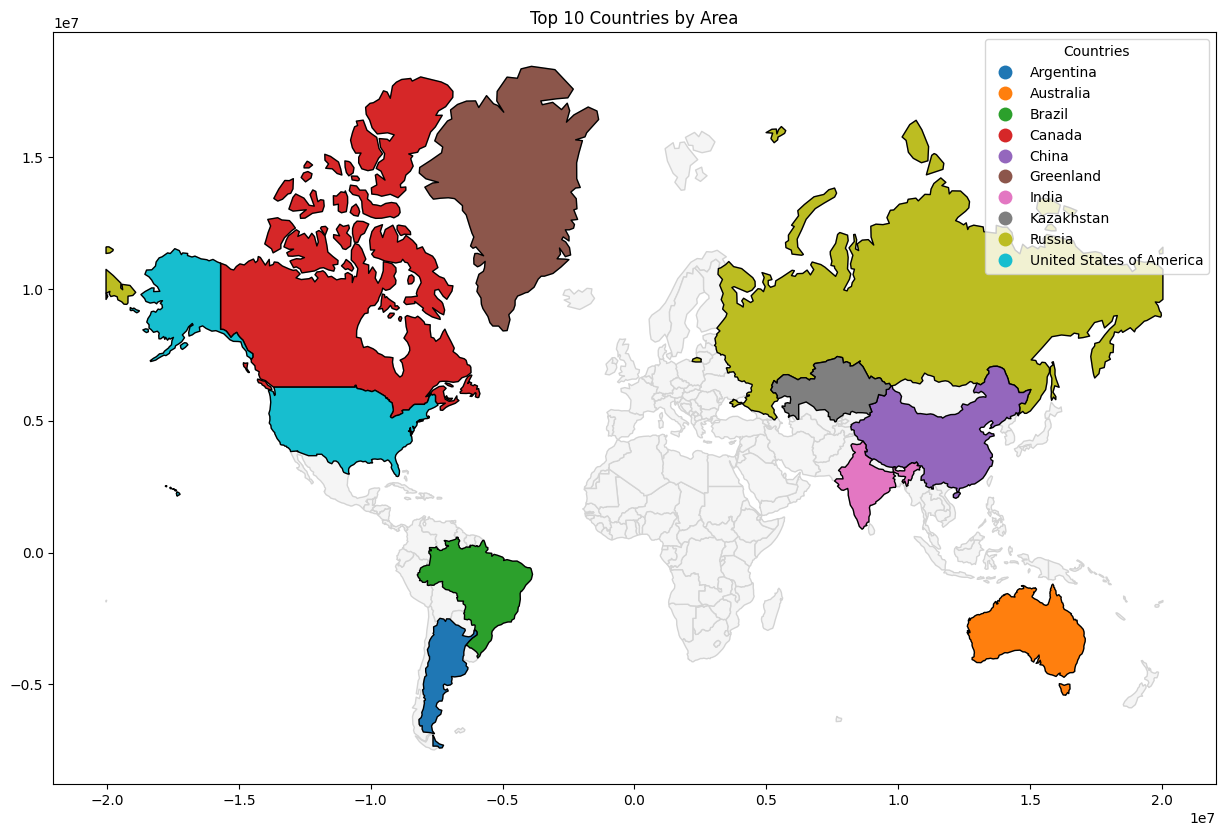

In [16]:
ax = remove.plot(figsize=(15,10), color="whitesmoke", edgecolor = "lightgrey")

top_10_countries.plot(
    ax=ax,
    edgecolor="black",
    column = "ADMIN",
    legend = True,
    categorical= True,
    cmap = "tab10",
    legend_kwds = {'title': 'Countries', 'bbox_to_anchor': (1,1)}
)

plt.title("Top 10 Countries by Area")
plt.show()

# **Reflection**


---

When ploting the top 10 largest area in the map, I've encountered a problem where Antarctica covers the whole map causing visual errors. Thus, to fix this problem, I've removed it from the plotting.

In Spatial Data, I've learned that EPSG:4326, is an essential coordinate system for spatial annalysis. With it, we are able to plot the top 10 largest countries in the Earth.